In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scienceplots
import sys
from scipy.interpolate import splev
from scipy.interpolate import interp1d
import os

plt.style.use('science')

# Line Spread Function (LSF)

In [2]:
#--Open Data--
lsffile_blue = 'data/CAL/lsf_BLUEL11_MOS-A.fits'
lsffile_red  = 'data/CAL/lsf_REDL11_MOS-A.fits'
lsffile_emiles = "e-miles_spectral_resolution.dat"

hdul = fits.open(lsffile_red)
data = hdul['LSF_splines'].data
available_nspec = data['NSPEC']

#--Define NSPEC--
nspec = 6

wl_red, flux_red, error_red = np.loadtxt(f'output/nspec/{nspec}/redflux_{nspec}.txt', delimiter='\t', unpack=True)
wl_blue, flux_blue, error_blue = np.loadtxt(f'output/nspec/{nspec}/blueflux_{nspec}.txt', delimiter='\t', unpack=True)

#-- Start a Dictionary --
arms = {
    'red':  dict(wl=wl_red,  flux=flux_red,  error=error_red,  lsffile=lsffile_red),
    'blue': dict(wl=wl_blue, flux=flux_blue, error=error_blue, lsffile=lsffile_blue)}

In [3]:
def getfwhm(file, nspec_list, wl, verbose=False):
    """
    Evaluate FWHM for a list of nspec values across given wavelengths,
    using spline fits stored in a WEAVE LSF FITS file.

    Parameters
    ----------
    file       : str   – path to the LSF FITS file
    nspec_list : array – fibre numbers to evaluate (will snap to nearest available)
    wl         : array – wavelengths in Angstrom at which to evaluate the FWHM
    verbose    : bool  – if True, print warnings when nspec is not found exactly

    Returns
    -------
    fwhm_array        : ndarray, shape (N_nspec, N_wl) – FWHM in Angstrom
    actual_nspec_array: ndarray, shape (N_nspec,)      – actual fibre numbers used
    """
    wl           = np.asarray(wl, dtype=float)
    nspec_array  = np.asarray(nspec_list, dtype=int).ravel()

    with fits.open(file) as hdul:
        data            = hdul['LSF_splines'].data
        available_nspec = data['NSPEC']
        wl_min          = hdul[0].header['MINWL']
        wl_max          = hdul[0].header['MAXWL']

        # Precompute masks (same for all nspec)
        below_range  = wl < wl_min
        above_range  = wl > wl_max
        within_range = ~below_range & ~above_range

        fwhm_list = []; actual_nspec_list = []

        for ns in nspec_array:
            # Snap to nearest available nspec
            idx = np.abs(available_nspec - ns).argmin()
            actual_nspec = int(available_nspec[idx])

            if verbose and actual_nspec != ns:
                print(f"Warning: nspec {ns} not found, using nearest: {actual_nspec}")

            tck = (data['t'][idx], data['c'][idx], int(data['k'][idx]))

            fwhm = np.empty_like(wl)
            if np.any(within_range): fwhm[within_range] = splev(wl[within_range], tck)
            if np.any(below_range): fwhm[below_range]  = splev(wl_min, tck)
            if np.any(above_range): fwhm[above_range]  = splev(wl_max, tck)

            fwhm_list.append(fwhm)
            actual_nspec_list.append(actual_nspec)

    fwhm_array = np.stack(fwhm_list) if fwhm_list else np.empty((0, wl.size))
    actual_nspec_array = np.array(actual_nspec_list, dtype=int)

    return fwhm_array, actual_nspec_array

## VisualizeLSF Across Different Fibres

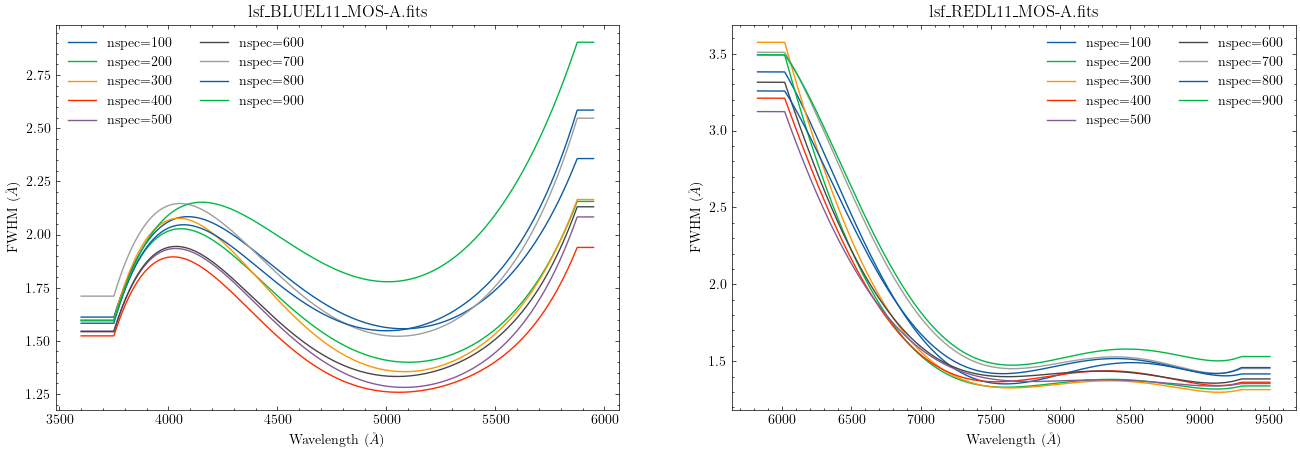

In [4]:
nspec_sample = np.arange(100, 901, 100) # 9 values sampled every 100 fibres

fwhm_blue_sample, actual_nspec_blue_sample = getfwhm(lsffile_blue, nspec_sample, wl_blue)
fwhm_red_sample,  actual_nspec_red_sample  = getfwhm(lsffile_red,  nspec_sample, wl_red)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for f, n in zip(fwhm_blue_sample, actual_nspec_blue_sample):
    ax[0].plot(wl_blue, f, label=f"nspec={n}")
ax[0].set_title(lsffile_blue.split('/')[-1])
ax[0].set_xlabel(r'Wavelength ($\AA$)')
ax[0].set_ylabel(r'FWHM ($\AA$)')
ax[0].legend(ncol=2)
for f, n in zip(fwhm_red_sample, actual_nspec_red_sample):
    ax[1].plot(wl_red, f, label=f"nspec={n}")
ax[1].set_title(lsffile_red.split('/')[-1])
ax[1].set_xlabel(r'Wavelength ($\AA$)')
ax[1].set_ylabel(r'FWHM ($\AA$)')
ax[1].legend(ncol=2)
plt.show()

In [5]:
'''
nspec_array  = np.arange(1, 961)

fwhm_blue, actual_nspec_blue = getfwhm(lsffile_blue, nspec_array, wl_blue)
fwhm_red,  actual_nspec_red  = getfwhm(lsffile_red,  nspec_array, wl_red)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, fwhm, actual_nspec, wlrange, title in zip(
    axes,
    [fwhm_blue, fwhm_red],
    [actual_nspec_blue, actual_nspec_red],
    [wl_blue, wl_red],
    ['MOS BLUEL11 - Plate MOS-A', 'MOS REDL11 - Plate MOS-A']
):
    im = ax.imshow(
        fwhm,
        origin='lower',
        aspect='auto',
        extent=[wlrange[0], wlrange[-1], actual_nspec[0], actual_nspec[-1]],
        cmap='jet',
        vmin=1.0, vmax=2.8
    )
    fig.colorbar(im, ax=ax, label=r'FWHM ($\AA$)')
    ax.set_xlabel(r'Wavelength ($\AA$)')
    ax.set_ylabel('nspec')
    ax.set_title(title)

plt.tight_layout()
plt.show()
'''

"\nnspec_array  = np.arange(1, 961)\n\nfwhm_blue, actual_nspec_blue = getfwhm(lsffile_blue, nspec_array, wl_blue)\nfwhm_red,  actual_nspec_red  = getfwhm(lsffile_red,  nspec_array, wl_red)\n\nfig, axes = plt.subplots(1, 2, figsize=(16, 8))\n\nfor ax, fwhm, actual_nspec, wlrange, title in zip(\n    axes,\n    [fwhm_blue, fwhm_red],\n    [actual_nspec_blue, actual_nspec_red],\n    [wl_blue, wl_red],\n    ['MOS BLUEL11 - Plate MOS-A', 'MOS REDL11 - Plate MOS-A']\n):\n    im = ax.imshow(\n        fwhm,\n        origin='lower',\n        aspect='auto',\n        extent=[wlrange[0], wlrange[-1], actual_nspec[0], actual_nspec[-1]],\n        cmap='jet',\n        vmin=1.0, vmax=2.8\n    )\n    fig.colorbar(im, ax=ax, label=r'FWHM ($\\AA$)')\n    ax.set_xlabel(r'Wavelength ($\\AA$)')\n    ax.set_ylabel('nspec')\n    ax.set_title(title)\n\nplt.tight_layout()\nplt.show()\n"

In [6]:
# Get WEAVE LSF for the single test galaxy
for arm in arms.values():
    fwhm, actual_nspec = getfwhm(arm['lsffile'], nspec, arm['wl'])
    arm['fwhm'] = fwhm[0]

# Get LSF for stellar template EMILES
wl_emiles, fwhm_emiles = np.loadtxt(lsffile_emiles, unpack=True, usecols=(0, 1))

# Smoothing BESTA Method

In [7]:
from besta.kinematics import convolve_variable_gaussian_kernel

def smooth_weave_to_emiles(flux, wl_weave, fwhm_weave, wl_emiles, fwhm_emiles):
    """
    Smooth a WEAVE spectrum to E-MILES resolution using a spatially-varying
    Gaussian kernel.

    Parameters
    ----------
    flux : np.ndarray
        WEAVE flux array (same length as wl_weave).
    wl_weave : np.ndarray
        WEAVE wavelength grid [Å].
    fwhm_weave : np.ndarray
        FWHM of the WEAVE LSF at each pixel [Å] (same length as wl_weave).
    wl_emiles : np.ndarray
        E-MILES wavelength grid [Å].
    fwhm_emiles : np.ndarray
        FWHM of the E-MILES LSF at each pixel [Å] (same length as wl_emiles).

    Returns
    -------
    flux_smoothed : np.ndarray
        WEAVE flux smoothed to E-MILES resolution.
    sigma_pixel : np.ndarray
        The smoothing kernel sigma at each pixel [pixel units], for diagnostics.
    fwhm_emiles_resampled : np.ndarray
        E-MILES FWHM interpolated onto the WEAVE wavelength grid [Å].
    """
    # 1. Interpolate E-MILES LSF onto WEAVE wavelength grid
    emiles_interp = interp1d(
        wl_emiles, fwhm_emiles,
        bounds_error=False,
        fill_value=(fwhm_emiles[0], fwhm_emiles[-1])
    )
    fwhm_emiles_resampled = emiles_interp(wl_weave)

    # 2. Quadrature difference: FWHM of the kernel needed [Å²]
    diff2 = fwhm_emiles_resampled**2 - fwhm_weave**2
    sigma2_aa = np.where(diff2 > 0, diff2, 0.0) / (2.3548**2)

    # 3. Convert sigma from Å to pixel units using local pixel scale
    dpix = np.gradient(wl_weave)          # Å/pixel at each pixel
    sigma_pixel = np.sqrt(sigma2_aa) / dpix

    # 4. Convolve
    flux_smoothed = convolve_variable_gaussian_kernel(flux.reshape(1, -1), sigma_pixel).squeeze()
    
    return flux_smoothed, sigma_pixel, fwhm_emiles_resampled


In [8]:
# ── Compute the smoothed LSF ─
def smoothed_fwhm(fwhm_weave, fwhm_emiles_resampled):
    """
    The effective FWHM after smoothing is simply fwhm_emiles where smoothing
    was applied, and fwhm_weave where it wasn't (target already exceeded).
    """
    smoothing_applied = fwhm_emiles_resampled > fwhm_weave
    return np.where(smoothing_applied, fwhm_emiles_resampled, fwhm_weave)

In [9]:
# Process both arms in one loop
for arm_name, arm in arms.items():
    arm['flux_smoothed'], arm['sigma_pix'], arm['fwhm_emiles_resampled']= smooth_weave_to_emiles(arm['flux'], arm['wl'], arm['fwhm'], wl_emiles, fwhm_emiles)
    arm['fwhm_smoothed']  = smoothed_fwhm(arm['fwhm'], arm['fwhm_emiles_resampled'])

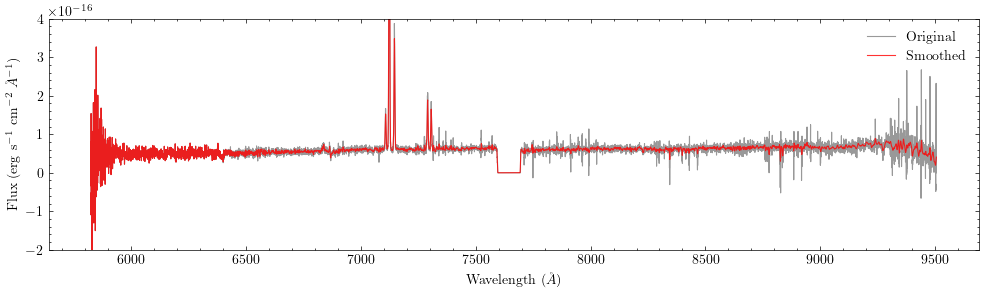

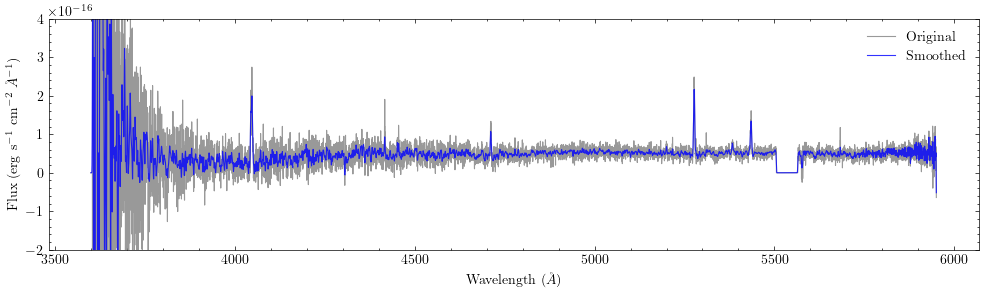

In [10]:
for arm_name, arm in arms.items():
    fig, ax = plt.subplots(1, 1, figsize=(12, 3), sharex=True)
    ax.plot(arm['wl'], arm['flux'], label='Original', lw=0.8, alpha=0.8, color='gray')
    ax.plot(arm['wl'], arm['flux_smoothed'], label='Smoothed', lw=0.8, alpha=0.8, color=f'{arm_name}')
    ax.set_ylabel(r'Flux (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)')
    ax.set_xlabel(r'Wavelength ($\AA$)')
    ax.set_ylim(-0.2e-15, 0.4e-15)
    ax.legend()
    plt.savefig(f"plots/smoothed_{arm_name}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Show original vs smoothed FWHM

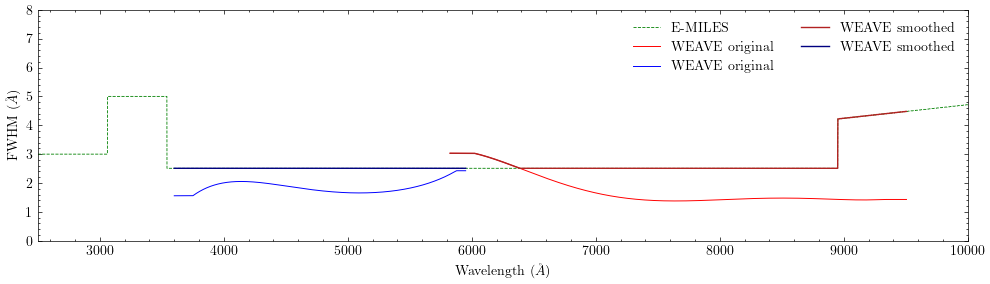

In [11]:
fig, ax = plt.subplots(figsize=(12, 3))

# Plot Emiles
ax.plot(wl_emiles, fwhm_emiles, color="green", ls="--", label="E-MILES", lw=0.6)

# Plot Original FWHM
ax.plot(wl_red, arms['red']['fwhm'], color="red", lw=0.7, label="WEAVE original")
ax.plot(wl_blue, arms['blue']['fwhm'], color="blue", lw=0.7, label="WEAVE original")

# Plot New FWHM
ax.plot(wl_red, arms['red']['fwhm_smoothed'], color="firebrick", label="WEAVE smoothed")
ax.plot(wl_blue, arms['blue']['fwhm_smoothed'], color="navy", label="WEAVE smoothed")

ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"FWHM ($\AA$)")
ax.set_xlim(2500, 10000)
ax.set_ylim(0, 8)
ax.legend(ncol=2)
plt.savefig(f"plots/smoothed_fwhm.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)